In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [4]:
df.duplicated().sum()

np.int64(418)

In [5]:
df.drop_duplicates(keep = "last", inplace=True)

In [6]:
df.shape

(49582, 2)

In [7]:
labels = {"negative" : 0, "positive" : 1}

# Feature Target
X = df.review
y = df.sentiment

target = y.replace(labels).to_numpy()

# Text Processing

In [8]:
import re
import nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [9]:
lemmatizer = nltk.stem.WordNetLemmatizer()

In [10]:
def text_processor(text: str) -> str:
    text = text.lower()

    # HTML Tags, URLs, Puncuation and Special Chars
    text = re.sub(r"<.+?>", "", text) # HTML TAGS
    text = re.sub(r"[(http(s)?):\/\/(www\.)?a-zA-Z0-9@:%._\+~#=]{2,256}\.[a-z]{2,6}\b([-a-zA-Z0-9@:%_\+.~#?&//=]*)", "", text) # URLS
    text = re.sub(r"[^\w\d\s]", " ", text) # Puncuation or special Chars
    text = text.strip()
    
    # Stopwords
    text = [word for word in text.split() if word not in ENGLISH_STOP_WORDS]
    text = [word for word in text if len(word) > 2]
    text = " ".join(text)

    # Lemmatization
    text = lemmatizer.lemmatize(text)

    return text
    

In [11]:
feature = X.apply(text_processor).to_numpy()

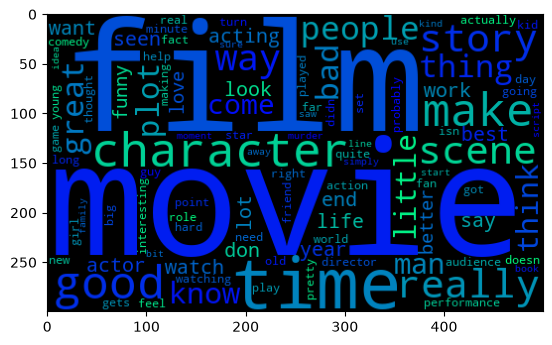

In [12]:
# Visualization

# !pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

cloud = WordCloud(
    colormap = "winter", max_words=100, width=500, height=300
)
image = cloud.generate(" ".join(feature[:500]))

plt.imshow(image)

## Vectorize or Embeddings

In [13]:
# TFIDF Vectorizer -> Train
# WOR2Vec -> Train or pretrained
# BERT -> Pretrained

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

In [15]:
# TFIDF Vectorizer -> Train

tfidf = TfidfVectorizer()
x_tfidf = tfidf.fit_transform(feature)

In [16]:
x_tfidf.shape

(49582, 102221)

In [17]:
# Wor2Vec -> Train or pretrained
tokens = [docs.split() for docs in feature]

w2v_model = Word2Vec(
    sentences= tokens,
    vector_size=250,
    window= 4,
    min_count= 2,
    workers=8
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [18]:
w2v_model.wv.get_vector("movie").shape

(250,)

In [19]:
# Word2Vec from Gensim
from gensim import downloader

google_w2v_model = downloader.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [20]:
google_w2v_model.most_similar("good")

[('great', 0.7291510105133057),
 ('bad', 0.7190051078796387),
 ('terrific', 0.6889115571975708),
 ('decent', 0.6837347745895386),
 ('nice', 0.6836092472076416),
 ('excellent', 0.644292950630188),
 ('fantastic', 0.6407778263092041),
 ('better', 0.6120728850364685),
 ('solid', 0.5806034803390503),
 ('lousy', 0.576420247554779)]

In [21]:
import numpy as np

def vectorizer(tokens, model):
    vectors = [ model[word] for word in tokens if word in model ]
    
    return np.mean(vectors, axis = 0 )
    

embedddings = np.array([
    vectorizer(token, google_w2v_model) for token in tokens
])

In [22]:
embedddings.shape

(49582, 300)

In [23]:
# BERT -> Pretrained

In [24]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
embedding_model = BertModel.from_pretrained("bert-base-uncased")

/Users/over/Documents/Code/Data Science & Machine Learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6244.14it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNE

In [25]:
bert_tokens = tokenizer(
    text = feature.tolist()[:10],
    padding=True,
    return_tensors= "pt"
)

In [26]:
bert_embeddings = embedding_model(**bert_tokens).last_hidden_state

In [27]:
bert_embeddings.shape

torch.Size([10, 152, 768])

## Classification Algorithm

In [28]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    embedddings, target.astype(int), test_size=0.2, stratify=target, shuffle=True, random_state=909
)

In [30]:
# logistic Regression
log_reg = LogisticRegression(max_iter=500, random_state=909)

In [31]:
log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",909
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [32]:
# Simple Vector Classifier SVC
svc = SVC(random_state=909)
svc.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",909
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [33]:
def evaluate(X_test, y_test, model):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    print("Evaluation Results")
    print("-" * 30)
    print("Confusion Matrix:")
    print(cm)
    print()
    print(f"F1 Score:  {f1:.4f}")
    print(f"Accuracy:  {acc:.4f}")


In [34]:
evaluate(X_test, y_test, log_reg)

Evaluation Results
------------------------------
Confusion Matrix:
[[4204  736]
 [ 723 4254]]

F1 Score:  0.8536
Accuracy:  0.8529


In [35]:
evaluate(X_test, y_test, svc)

Evaluation Results
------------------------------
Confusion Matrix:
[[4259  681]
 [ 676 4301]]

F1 Score:  0.8637
Accuracy:  0.8632


# Saving The model

In [36]:
import joblib

In [37]:
to_save = {
    "preprocessor" : text_processor,
    "vectorizer" : w2v_model,
    "classifier" : log_reg
}

In [38]:
joblib.dump(to_save, "../data/sentiment_classifier.joblib", compress = 3)

['../data/sentiment_classifier.joblib']